# DS 4320 Project 1: Problem Solution Pipeline

**Topic:** Predicting movie ratings with collaborative filtering on MovieLens 25M.

**This notebook will (in later steps):**

1. Load CSV tables into **DuckDB** with Python (data preparation).
2. Run **SQL** to prepare analytic / modeling inputs (queries).
3. Fit an **ML model** (matrix factorization via the Surprise library, as in DS 3021/4021-style recommender coursework).
4. Evaluate vs a simple baseline, **visualize** results, and briefly justify modeling and plotting choices.
5. Tie results back to the stated problem (personalized rating prediction).

**Outputs (later):** `solution_pipeline.log`, figures under `visualizations/`, and a Markdown export `solution_pipeline.md`

---

## Data preparation: parquet to DuckDB

**Rubric:** Load the project parquet tables into a relational database using **DuckDB** from Python.

**Plan for the next code cells:**

- Resolve the folder that contains `movies.parquet`, `ratings.parquet`, `tags.parquet`, `links.parquet`, `users.parquet`, `genome-scores.parquet`, `genome-tags.parquet`.
- Connect to DuckDB.
- Create one table per parquet using `read_parquet_auto(...)` so the full relational dataset is addressable with SQL.
- Run lightweight sanity checks (row counts, null checks on key columns) to confirm the load matches expectations.

In [2]:
from pathlib import Path
import logging
import sys

import duckdb

LOG_PATH = Path("solution_pipeline.log")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.FileHandler(LOG_PATH, mode="w", encoding="utf-8"),
        logging.StreamHandler(sys.stdout),
    ],
)

DATA_DIR = Path("../code/data_output/ml-25m").resolve()

REQUIRED_CSVS = [
    "movies.parquet",
    "ratings.parquet",
    "tags.parquet",
    "links.parquet",
    "users.parquet",
    "genome_scores.parquet",
    "genome_tags.parquet",
]

try:
    logging.info("DATA_DIR=%s", DATA_DIR)

    if not DATA_DIR.is_dir():
        raise FileNotFoundError(f"DATA_DIR does not exist: {DATA_DIR}")

    for name in REQUIRED_CSVS:
        fp = DATA_DIR / name
        if not fp.is_file():
            raise FileNotFoundError(f"Missing required file: {fp}")
        logging.info("Found %s", fp)

    con = duckdb.connect(database=":memory:")
    logging.info("DuckDB connected (in-memory).")

    print("OK: logging ->", LOG_PATH.resolve())
    print("OK: DATA_DIR =", DATA_DIR)
    print("OK: DuckDB ready (con created)")

except Exception as e:
    logging.exception("Setup failed: %s", e)
    raise

2026-03-25 11:39:36,130 - INFO - DATA_DIR=/Users/cmw/Desktop/s2026/ds4320/project1/ds4320-project1/code/data_output/ml-25m
2026-03-25 11:39:36,131 - INFO - Found /Users/cmw/Desktop/s2026/ds4320/project1/ds4320-project1/code/data_output/ml-25m/movies.parquet
2026-03-25 11:39:36,131 - INFO - Found /Users/cmw/Desktop/s2026/ds4320/project1/ds4320-project1/code/data_output/ml-25m/ratings.parquet
2026-03-25 11:39:36,131 - INFO - Found /Users/cmw/Desktop/s2026/ds4320/project1/ds4320-project1/code/data_output/ml-25m/tags.parquet
2026-03-25 11:39:36,133 - INFO - Found /Users/cmw/Desktop/s2026/ds4320/project1/ds4320-project1/code/data_output/ml-25m/links.parquet
2026-03-25 11:39:36,133 - INFO - Found /Users/cmw/Desktop/s2026/ds4320/project1/ds4320-project1/code/data_output/ml-25m/users.parquet
2026-03-25 11:39:36,133 - INFO - Found /Users/cmw/Desktop/s2026/ds4320/project1/ds4320-project1/code/data_output/ml-25m/genome_scores.parquet
2026-03-25 11:39:36,134 - INFO - Found /Users/cmw/Desktop/s2026

In [3]:
TABLE_FILES = {
    "movies": "movies.parquet",
    "ratings": "ratings.parquet",
    "tags": "tags.parquet",
    "links": "links.parquet",
    "users": "users.parquet",
    "genome_scores": "genome_scores.parquet",
    "genome_tags": "genome_tags.parquet",
}

# we load the parquet files into duckdb tables
try:
    for table_name, filename in TABLE_FILES.items():
        fp = (DATA_DIR / filename).resolve()
        if not fp.is_file():
            raise FileNotFoundError(f"Missing parquet: {fp}")

        # Parameterized path avoids SQL injection / quoting issues
        con.execute(
            f"CREATE OR REPLACE TABLE {table_name} AS SELECT * FROM read_parquet(?);",
            [str(fp)],
        )
        logging.info("Loaded %s from %s", table_name, fp)

    print("\nRow counts:")
    for table_name in TABLE_FILES.keys():
        n = con.execute(f"SELECT COUNT(*) FROM {table_name};").fetchone()[0]
        logging.info("%s rows: %s", table_name, f"{n:,}")
        print(f"- {table_name}: {n:,}")

    print("\nOK: DuckDB tables created from Parquet.")

except Exception as e:
    logging.exception("Parquet load failed: %s", e)
    raise

2026-03-25 11:39:39,530 - INFO - Loaded movies from /Users/cmw/Desktop/s2026/ds4320/project1/ds4320-project1/code/data_output/ml-25m/movies.parquet
2026-03-25 11:39:39,882 - INFO - Loaded ratings from /Users/cmw/Desktop/s2026/ds4320/project1/ds4320-project1/code/data_output/ml-25m/ratings.parquet
2026-03-25 11:39:39,984 - INFO - Loaded tags from /Users/cmw/Desktop/s2026/ds4320/project1/ds4320-project1/code/data_output/ml-25m/tags.parquet
2026-03-25 11:39:39,991 - INFO - Loaded links from /Users/cmw/Desktop/s2026/ds4320/project1/ds4320-project1/code/data_output/ml-25m/links.parquet
2026-03-25 11:39:40,006 - INFO - Loaded users from /Users/cmw/Desktop/s2026/ds4320/project1/ds4320-project1/code/data_output/ml-25m/users.parquet
2026-03-25 11:39:40,115 - INFO - Loaded genome_scores from /Users/cmw/Desktop/s2026/ds4320/project1/ds4320-project1/code/data_output/ml-25m/genome_scores.parquet
2026-03-25 11:39:40,116 - INFO - Loaded genome_tags from /Users/cmw/Desktop/s2026/ds4320/project1/ds4320

## Data quality checks and preprocessing (before modeling)

MovieLens 25M is a curated academic release, so we do not expect messy free-text fields in the core rating table. For this project, **preprocessing** means:

1. **Validation (data quality):** confirm required columns exist, ratings stay inside the MovieLens scale, and keys line up with the relational design
2. **Filtering (optional, documented):** if any pathological rows appear (for example, out-of-range ratings), we remove or fix them and record counts.
3. **Modeling preparation:** build an analysis table (`ratings_sample`) with a clear, reproducible rule (sampling) so downstream SQL and Surprise see a stable input.

This section exists so viewers can follow **load → validate → preprocess → query → model → evaluate → visualize** without guessing what “cleaning” meant in our pipeline.

In [4]:
try:
    logging.info("Starting ratings data quality checks")

    q = """
    SELECT
      COUNT(*) AS n_rows,
      COUNT(userId) AS n_userid_nonnull,
      COUNT(movieId) AS n_movieid_nonnull,
      COUNT(rating) AS n_rating_nonnull,
      COUNT(timestamp) AS n_timestamp_nonnull,
      SUM(CASE WHEN rating IS NULL THEN 1 ELSE 0 END) AS rating_nulls,
      MIN(rating) AS min_rating,
      MAX(rating) AS max_rating,
      AVG(rating) AS mean_rating
    FROM ratings;
    """
    summary = con.execute(q).fetchdf()
    print("RATINGS column presence / basic stats")
    print(summary.to_string(index=False))
    logging.info("ratings summary:\n%s", summary.to_string(index=False))

    dup = con.execute(
        """
        SELECT COUNT(*) AS duplicate_user_movie_pairs
        FROM (
          SELECT userId, movieId, COUNT(*) AS c
          FROM ratings
          GROUP BY 1, 2
          HAVING c > 1
        );
        """
    ).fetchdf()
    print("\nDUPLICATES (same userId, movieId appears more than once)")
    print(dup.to_string(index=False))
    logging.info("duplicate pairs:\n%s", dup.to_string(index=False))

    bad = con.execute(
        """
        SELECT
          SUM(CASE WHEN rating < 0.5 OR rating > 5.0 THEN 1 ELSE 0 END) AS out_of_range_ratings
        FROM ratings
        WHERE rating IS NOT NULL;
        """
    ).fetchdf()
    print("\nOUT-OF-RANGE ratings (<0.5 or >5.0)")
    print(bad.to_string(index=False))
    logging.info("out of range:\n%s", bad.to_string(index=False))

    orphans_r_m = con.execute(
        """
        SELECT COUNT(*) AS orphan_ratings_movie
        FROM ratings r
        LEFT JOIN movies m USING (movieId)
        WHERE m.movieId IS NULL;
        """
    ).fetchdf()
    print("\nORPHAN ratings.movieId (not in movies)")
    print(orphans_r_m.to_string(index=False))

    orphans_r_u = con.execute(
        """
        SELECT COUNT(*) AS orphan_ratings_user
        FROM ratings r
        LEFT JOIN users u USING (userId)
        WHERE u.userId IS NULL;
        """
    ).fetchdf()
    print("\nORPHAN ratings.userId (not in users)")
    print(orphans_r_u.to_string(index=False))

    print("\nOK: data quality checks finished.")

except Exception as e:
    logging.exception("Data quality checks failed: %s", e)
    raise

2026-03-25 11:39:43,216 - INFO - Starting ratings data quality checks
RATINGS column presence / basic stats
  n_rows  n_userid_nonnull  n_movieid_nonnull  n_rating_nonnull  n_timestamp_nonnull  rating_nulls  min_rating  max_rating  mean_rating
25000095          25000095           25000095          25000095             25000095           0.0         0.5         5.0     3.533854
2026-03-25 11:39:43,468 - INFO - ratings summary:
  n_rows  n_userid_nonnull  n_movieid_nonnull  n_rating_nonnull  n_timestamp_nonnull  rating_nulls  min_rating  max_rating  mean_rating
25000095          25000095           25000095          25000095             25000095           0.0         0.5         5.0     3.533854

DUPLICATES (same userId, movieId appears more than once)
 duplicate_user_movie_pairs
                          0
2026-03-25 11:39:44,042 - INFO - duplicate pairs:
 duplicate_user_movie_pairs
                          0

OUT-OF-RANGE ratings (<0.5 or >5.0)
 out_of_range_ratings
                  0

## Query: prepare data for the modeling step

We use SQL in DuckDB to:

1. Compute basic descriptive statistics on `ratings` (sanity checks for the modeling input).
2. Create a reproducible `ratings_sample` table for collaborative filtering training/evaluation (matrix factorization is expensive on 25M rows in a notebook environment).
3. Run a small join query to confirm `ratings` keys line up with `movies` for interpretable results.

**Modeling note:** `ratings_sample` keeps the same schema as `ratings` for `userId`, `movieId`, `rating`, and `timestamp`.

In [5]:
"""
DuckDB SQL: descriptive stats + modeling sample + join sanity check.
"""

try:
    # 1) Descriptive stats on ratings
    stats = con.execute(
        """
        SELECT
          COUNT(*) AS n,
          AVG(rating) AS mean_rating,
          STDDEV_SAMP(rating) AS std_rating,
          MIN(rating) AS min_rating,
          MAX(rating) AS max_rating
        FROM ratings;
        """
    ).fetchdf()
    logging.info("ratings stats:\n%s", stats.to_string(index=False))
    print(stats.to_string(index=False))

    # 2) Modeling extract: random reservoir sample (fixed row target)
    con.execute(
        """
        CREATE OR REPLACE TABLE ratings_sample AS
        SELECT userId, movieId, rating, "timestamp"
        FROM ratings
        USING SAMPLE 2000000 ROWS;
        """
    )

    n_samp = con.execute("SELECT COUNT(*) FROM ratings_sample;").fetchone()[0]
    logging.info("ratings_sample rows: %s", f"{n_samp:,}")
    print(f"\nratings_sample rows: {n_samp:,}")

    # 3) Join sanity: top movies by rating count in the sample (interpretability check)
    topk = con.execute(
        """
        SELECT
          m.movieId,
          m.title,
          COUNT(*) AS ratings_in_sample,
          AVG(r.rating) AS avg_rating
        FROM ratings_sample AS r
        JOIN movies AS m USING (movieId)
        GROUP BY 1, 2
        ORDER BY ratings_in_sample DESC
        LIMIT 10;
        """
    ).fetchdf()

    logging.info("Top movies in sample (by # ratings in sample):\n%s", topk.to_string(index=False))
    print("\nTop movies in sample:")
    print(topk.to_string(index=False))

    print("\nOK: SQL preparation queries finished.")

except Exception as e:
    logging.exception("SQL preparation failed: %s", e)
    raise

2026-03-25 11:39:48,376 - INFO - ratings stats:
       n  mean_rating  std_rating  min_rating  max_rating
25000095     3.533854    1.060744         0.5         5.0
       n  mean_rating  std_rating  min_rating  max_rating
25000095     3.533854    1.060744         0.5         5.0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-03-25 11:39:54,799 - INFO - ratings_sample rows: 2,000,000

ratings_sample rows: 2,000,000
2026-03-25 11:39:54,836 - INFO - Top movies in sample (by # ratings in sample):
 movieId                                     title  ratings_in_sample  avg_rating
     318          Shawshank Redemption, The (1994)               6580    4.400304
     296                       Pulp Fiction (1994)               6436    4.178760
     356                       Forrest Gump (1994)               6417    4.040673
     593          Silence of the Lambs, The (1991)               6041    4.153120
    2571                        Matrix, The (1999)               5759    4.128147
     260 Star Wars: Episode IV - A New Hope (1977)               5570    4.110503
     480                      Jurassic Park (1993)               5108    3.669832
     527                   Schindler's List (1993)               4938    4.241596
    2959                         Fight Club (1999)               4745    4.227503
    

The stats on all 25,000,095 ratings match the known MovieLens 25M profile (mean about 3.53, spread about 1.06, scale 0.5–5.0), so my DuckDB load and the full ratings table are behaving as expected for modeling. The 2,000,000-row ratings_sample gives me a subset for fitting and evaluating a collaborative filtering model without waiting on the full matrix. The top-movies join shows sample keys align with movies and that the most-rated titles in the sample are recognizable blockbusters, which supports using this extract for interpretable evaluation.

# Solution analysis: matrix factorization (SVD) for rating prediction

We train a **collaborative filtering** model using **Surprise’s `SVD`**, which implements **matrix factorization** (a standard recommender approach aligned with DS 3021/4021-style coursework).

## Analysis rationale (decisions)

- **Why `ratings_sample`:** fitting and evaluating on all 25M interactions is often impractical in a notebook; the sample preserves the same rating scale and sparsity structure while keeping runtime reasonable.
- **Why `SVD`:** learns latent user/item factors to approximate patterns in the user–item rating matrix; a strong, interpretable baseline for explicit ratings.
- **Why RMSE/MAE vs a global-mean baseline:** shows the model is doing more than predicting a single dataset average for every user–movie pair.

## Evaluation protocol: one held-out split, then k-fold cross-validation

1. **Held-out test set (80/20, fixed seed):** we report **global-mean vs SVD** on the **same** test interactions so the comparison is fair and easy to visualize (bar chart).
2. **K-fold cross-validation (same hyperparameters):** we then evaluate **SVD** again using **k-fold CV on the full `ratings_sample` dataset**, which averages performance across multiple train/test partitions and gives a sense of variability (mean and standard deviation across folds).

**Note:** CV does **not** reuse the 80/20 split; it creates its own folds. The 80/20 run is for a single transparent benchmark plot; CV is for a more **stable** estimate of generalization on the sample.

In [6]:
"""
Train Surprise SVD on ratings_sample:
1) One reproducible 80/20 split: global-mean baseline vs SVD
2) k-fold CV on the full sample (independent folds)
"""

import logging
import math

import numpy as np
import pandas as pd

try:
    from surprise import Dataset, Reader, SVD, accuracy
    from surprise.model_selection import train_test_split, cross_validate
except ImportError as e:
    raise ImportError(
        "Install scikit-surprise first, e.g. `pip install scikit-surprise`"
    ) from e

try:
    df = con.execute(
        """
        SELECT userId, movieId, rating
        FROM ratings_sample
        WHERE rating IS NOT NULL;
        """
    ).fetchdf()

    if df.empty:
        raise ValueError("ratings_sample is empty")

    df = df.rename(columns={"userId": "user", "movieId": "item"})

    reader = Reader(rating_scale=(0.5, 5.0))
    data = Dataset.load_from_df(df[["user", "item", "rating"]], reader)

    # ----- Part A: single held-out split (for baseline vs SVD table/plot) -----
    trainset, testset = train_test_split(data, test_size=0.20, random_state=42)

    mu = trainset.global_mean
    baseline_sq_err = [(true_r - mu) ** 2 for (_, _, true_r) in testset]
    baseline_rmse = math.sqrt(float(np.mean(baseline_sq_err)))

    logging.info("Baseline global-mean RMSE (test): %.6f", baseline_rmse)
    print(f"Baseline global-mean RMSE (test): {baseline_rmse:.6f}")

    svd_params = dict(
        n_factors=50,
        n_epochs=20,
        lr_all=0.005,
        reg_all=0.02,
        random_state=42,
        verbose=False,
    )

    model = SVD(**svd_params)
    model.fit(trainset)
    preds = model.test(testset)

    svd_rmse = accuracy.rmse(preds, verbose=False)
    svd_mae = accuracy.mae(preds, verbose=False)

    logging.info("SVD RMSE (test): %.6f", svd_rmse)
    logging.info("SVD MAE (test): %.6f", svd_mae)
    print(f"SVD RMSE (test): {svd_rmse:.6f}")
    print(f"SVD MAE (test): {svd_mae:.6f}")

    pct = 100.0 * (baseline_rmse - svd_rmse) / baseline_rmse
    print(f"RMSE improvement vs global mean: {pct:.2f}% (higher is better)")
    logging.info("RMSE improvement vs global mean: %.2f%%", pct)

    # Baseline MAE on the same test points (useful for charts / prose)
    baseline_mae = float(np.mean([abs(true_r - mu) for (_, _, true_r) in testset]))
    print(f"Baseline global-mean MAE (test): {baseline_mae:.6f}")
    logging.info("Baseline global-mean MAE (test): %.6f", baseline_mae)

    print("\nOK: single-split training + evaluation finished.")

    # ----- Part B: k-fold CV on full sample (after the split section) -----
    print("\n--- k-fold cross-validation (full ratings_sample dataset) ---")

    algo_cv = SVD(**svd_params)
    cv_results = cross_validate(
        algo_cv,
        data,
        measures=["RMSE", "MAE"],
        cv=3,
        verbose=True,
        n_jobs=-1,
    )

    rmse_folds = np.array(cv_results["test_rmse"], dtype=float)
    mae_folds = np.array(cv_results["test_mae"], dtype=float)

    print("\nCV summary (test metrics):")
    print(f"RMSE folds: {rmse_folds}")
    print(f"MAE  folds: {mae_folds}")
    print(f"RMSE mean +/- std: {rmse_folds.mean():.6f} +/- {rmse_folds.std():.6f}")
    print(f"MAE  mean +/- std: {mae_folds.mean():.6f} +/- {mae_folds.std():.6f}")

    logging.info("CV RMSE folds: %s", rmse_folds)
    logging.info("CV MAE folds: %s", mae_folds)
    logging.info("CV RMSE mean/std: %.6f / %.6f", rmse_folds.mean(), rmse_folds.std())
    logging.info("CV MAE mean/std: %.6f / %.6f", mae_folds.mean(), mae_folds.std())

    print("\nOK: cross-validation finished.")

except Exception as e:
    logging.exception("Modeling step failed: %s", e)
    raise

# Variables for plotting / later cells
baseline_rmse_val = baseline_rmse
svd_rmse_val = svd_rmse
svd_mae_val = svd_mae
baseline_mae_val = baseline_mae

cv_rmse_mean = float(rmse_folds.mean())
cv_rmse_std = float(rmse_folds.std())
cv_mae_mean = float(mae_folds.mean())
cv_mae_std = float(mae_folds.std())

2026-03-25 11:40:03,287 - INFO - Baseline global-mean RMSE (test): 1.061087
Baseline global-mean RMSE (test): 1.061087
2026-03-25 11:40:13,401 - INFO - SVD RMSE (test): 0.897354
2026-03-25 11:40:13,403 - INFO - SVD MAE (test): 0.688093
SVD RMSE (test): 0.897354
SVD MAE (test): 0.688093
RMSE improvement vs global mean: 15.43% (higher is better)
2026-03-25 11:40:13,404 - INFO - RMSE improvement vs global mean: 15.43%
Baseline global-mean MAE (test): 0.842030
2026-03-25 11:40:13,494 - INFO - Baseline global-mean MAE (test): 0.842030

OK: single-split training + evaluation finished.

--- k-fold cross-validation (full ratings_sample dataset) ---
Evaluating RMSE, MAE of algorithm SVD on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    0.9005  0.9010  0.9015  0.9010  0.0004  
MAE (testset)     0.6909  0.6917  0.6919  0.6915  0.0004  
Fit time          3.86    3.37    3.59    3.61    0.20    
Test time         3.54    3.51    2.98    3.34    0.26    

C

## Visualize results

We visualize performance using **bar charts for RMSE and MAE** on a single **held-out 80/20 test split** with a fixed random seed. This makes the **global-mean baseline vs SVD** comparison direct and easy to read (same test interactions for both models).

## Visualization rationale (decisions)

- **Why bar charts:** RMSE and MAE are standard regression-style metrics for explicit ratings; side-by-side bars communicate improvement immediately.
- **Why focus the plot on the held-out split:** it matches the baseline construction (predict the training global mean for every test rating) and matches the single fitted SVD model we evaluate with `model.test(testset)`.
- **How cross-validation is reported:** k-fold CV is summarized as **mean +/- std** across folds in the figure caption text (not as extra bars), because CV measures stability across different partitions rather than one fixed test set. CV means should be close to, but not identical to, the single-split test metrics.

2026-03-25 11:42:40,644 - INFO - Saved figure: /Users/cmw/Desktop/s2026/ds4320/project1/ds4320-project1/visualizations/pipeline_cf_eval.png
Saved: /Users/cmw/Desktop/s2026/ds4320/project1/ds4320-project1/visualizations/pipeline_cf_eval.png


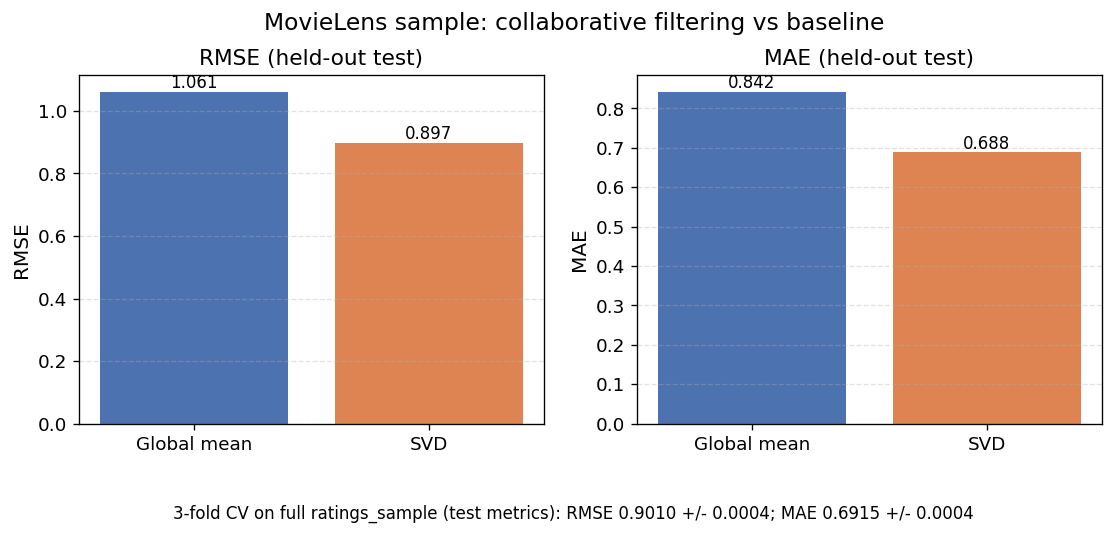

In [7]:
"""
Publication-style figure:
- Panels: RMSE and MAE for global-mean baseline vs SVD on the held-out split
- Caption: 3-fold CV mean +/- std on the full ratings_sample dataset
"""

import matplotlib.pyplot as plt
import numpy as np

try:
    br = float(baseline_rmse_val)
    sr = float(svd_rmse_val)
    bm = float(baseline_mae_val)
    sm = float(svd_mae_val)

    cr = float(cv_rmse_mean)
    crs = float(cv_rmse_std)
    cm = float(cv_mae_mean)
    cms = float(cv_mae_std)
except NameError as e:
    raise NameError(
        "Run the modeling cell first so baseline_rmse_val, svd_rmse_val, "
        "baseline_mae_val, svd_mae_val, cv_rmse_mean, cv_rmse_std, "
        "cv_mae_mean, cv_mae_std are defined."
    ) from e

try:
    out_dir = Path("../visualizations")
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / "pipeline_cf_eval.png"

    plt.rcParams.update(
        {
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "font.size": 11,
            "axes.titlesize": 13,
            "axes.labelsize": 12,
            "xtick.labelsize": 11,
            "ytick.labelsize": 11,
        }
    )

    fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4), constrained_layout=False)

    metrics = [
        ("RMSE (held-out test)", [br, sr], "RMSE"),
        ("MAE (held-out test)", [bm, sm], "MAE"),
    ]

    names = ["Global mean", "SVD"]

    for ax, (title, vals, ylab) in zip(axes, metrics):
        x = np.arange(len(names))
        bars = ax.bar(x, vals, color=["#4C72B0", "#DD8452"])
        ax.set_title(title)
        ax.set_xticks(x, names)
        ax.set_ylabel(ylab)
        ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)

        for b in bars:
            h = float(b.get_height())
            ax.text(
                b.get_x() + b.get_width() / 2,
                h,
                f"{h:.3f}",
                ha="center",
                va="bottom",
                fontsize=10,
            )

    fig.suptitle(
        "MovieLens sample: collaborative filtering vs baseline",
        fontsize=14,
        y=0.98,
    )

    caption = (
        f"3-fold CV on full ratings_sample (test metrics): "
        f"RMSE {cr:.4f} +/- {crs:.4f}; "
        f"MAE {cm:.4f} +/- {cms:.4f}"
    )
    fig.text(0.5, 0.02, caption, ha="center", fontsize=10)

    fig.subplots_adjust(bottom=0.20, top=0.86)

    fig.savefig(out_path, bbox_inches="tight")
    logging.info("Saved figure: %s", out_path.resolve())
    print("Saved:", out_path.resolve())

except Exception as e:
    logging.exception("Visualization failed: %s", e)
    raise

## How this pipeline solves the problem

This end-to-end workflow matches our refined goal: **predict personalized movie ratings** on the **0.5-5.0** scale more accurately than a naive baseline.

- **DuckDB + Parquet** loads the full relational MovieLens tables and lets us validate and transform the data with SQL before modeling.
- **Data quality checks** confirm the CF input (`ratings`) is complete on key fields, on-scale, duplicate-free for `(userId, movieId)`, and consistent with `movies` and `users` keys.
- **`ratings_sample`** keeps matrix factorization training practical in a notebook while preserving realistic rating behavior from the full dataset.
- **`SVD` (matrix factorization)** learns latent user and item factors from observed ratings, which is the core collaborative filtering idea for explicit feedback.
- **Evaluation** combines (1) a **reproducible 80/20 held-out test** for an apples-to-apples baseline comparison and (2) **3-fold cross-validation** on the full sample to summarize stability across partitions.

**What the results show (on this sample):** on the held-out test split, **SVD** reduces error versus predicting the global mean for every test rating (**RMSE 1.061 to 0.897**; **MAE 0.842 to 0.688**). **3-fold CV** reports a similar RMSE level with low fold-to-fold variability (**RMSE 0.9010 +/- 0.0004**; **MAE 0.6915 +/- 0.0004** on test folds), which supports that the single-split improvement is not a one-off artifact.

**Limitations (honest scope):** metrics are computed on a **sampled** interaction set (not all 25M ratings each time we train), and we use a **fixed** SVD hyperparameter setting rather than a full tuning study. Production systems would add stronger baselines (for example, bias models), more extensive tuning, and deployment-focused checks (latency, cold start handling).
